# GlobalFit column-charge analysis

Interactive comparison of any number of column-fit light maps with common MC truth. The notebook studies geometry and column convergence, fitted $q_k$ versus true column energy, and MC-segment residuals to the reconstructed line. A straight line fitted only to primary-muon MC points is included as the intrinsic truth reference.

Run the cells in order. Change only `FIT_FILES` and `TRUTH_MODE` for the usual workflow. All ROOT files must have been produced from the same events.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'column_fit_notebook_tools.py').exists():
    NOTEBOOK_DIR = Path('/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/GlobalFitTest')
sys.path.insert(0, str(NOTEBOOK_DIR))
from column_fit_notebook_tools import *
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .2})

## Configuration

Add, remove, or rename entries freely. `TRUTH_MODE='all'` compares $q_k$ with all HOMO energy deposits, including delta electrons and other secondaries. Use `'primary_muon'` to retain only segments attributed to the simulated muon track.

In [2]:
BASE = Path('/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps')
def preferred_fit(directory):
    directory = BASE / directory
    mip = directory / 'global_fit_columns_mip_1mm.root'
    legacy = directory / 'global_fit_columns_particle_ids.root'
    return mip if mip.exists() else legacy

FIT_FILES = {
    '0.25 mm': preferred_fit('10bin_5m_0p25mm_100kPhotons'),
    '0.4 mm':  preferred_fit('10bin_5m_0p4mm_100kPhotons'),
    '0.7 mm':  preferred_fit('10bin_5m_0p7mm_100kPhotons'),
    '1.0 mm':  preferred_fit('250514_10bin_5m_1mm_100kPhotons'),
}
TRUTH_MODE = 'all'  # 'all' or 'primary_muon'
studies = load_studies(FIT_FILES)
reference_file = next(iter(studies.values()))['path']
segments, track_points = load_truth(reference_file)
print(f'Loaded {len(studies)} light maps; MC reference: {reference_file}')

Loaded 4 light maps; MC reference: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_0p25mm_100kPhotons/global_fit_columns_mip_1mm.root


## Convergence

Geometry convergence is the Minuit status/EDM from the first stage. Column convergence is independent: it requires the largest relative EM update to fall below $10^{-6}$. NLL improvements are positive when the corresponding stage improves the likelihood.

,events,geometry_status_0,geometry_status_3,geometry_status_5,column_results,column_converged,column_converged_fraction,median_edm,median_column_iterations
lightmap,,,,,,,,,
0.25 mm,505,0,107,398,505,414,0.819802,0.007573,260.0
0.4 mm,505,0,111,394,505,398,0.788119,0.007302,422.0
0.7 mm,505,0,113,392,505,375,0.742574,0.007523,598.0
1.0 mm,505,0,103,402,505,360,0.712871,0.007349,802.0


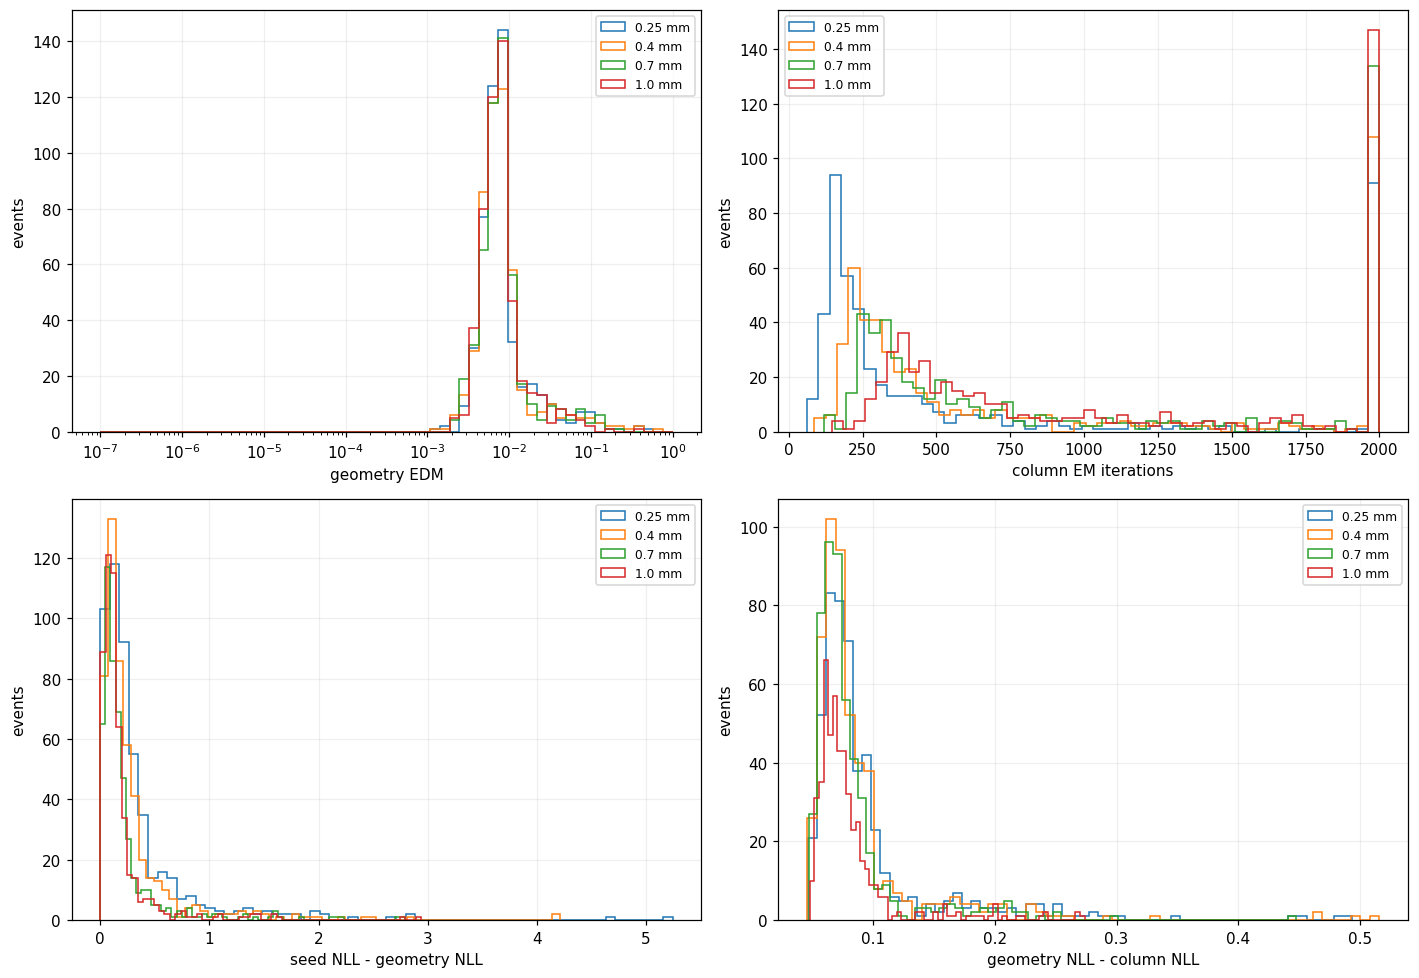

In [3]:
display(convergence_table(studies))
plot_convergence(studies);

In [4]:
# Event-level table for sorting and inspecting failures.
diagnostics = []
for label, study in studies.items():
    frame = study['fit'].copy()
    frame.insert(0, 'lightmap', label)
    for name in ['column_fit_converged','column_fit_iterations','column_fit_max_relative_change','column_fit_active_columns','column_nll']:
        if name not in frame: frame[name] = np.nan
    frame['geometry_nll_improvement'] = frame.seed_nll - frame.nll
    frame['column_nll_improvement'] = frame.nll - frame.column_nll
    diagnostics.append(frame)
diagnostics = pd.concat(diagnostics, ignore_index=True)
display(diagnostics[['lightmap','event','status','edm','function_calls','chi2','ndof',
                     'column_fit_converged','column_fit_iterations','column_fit_max_relative_change',
                     'column_fit_active_columns','geometry_nll_improvement','column_nll_improvement']]
        .sort_values(['column_fit_converged','edm'], ascending=[True,False]).head(100))

,lightmap,event,status,edm,function_calls,chi2,ndof,column_fit_converged,column_fit_iterations,column_fit_max_relative_change,column_fit_active_columns,geometry_nll_improvement,column_nll_improvement
50,0.25 mm,50,3,0.543292,11,2838.347818,388,0,2000,0.000002,111,0.077116,0.230193
366,0.25 mm,366,3,0.429141,10,222248.884830,522,0,2000,0.010354,109,0.000000,0.350090
1706,1.0 mm,191,3,0.379050,8,4547.027889,550,0,2000,0.006600,110,0.019463,0.159889
684,0.4 mm,179,3,0.255967,40,36845.016536,593,0,2000,0.002747,110,4.211126,0.201845
772,0.4 mm,267,3,0.252368,12,3349.920069,486,0,2000,0.004034,108,0.161557,0.094962
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1974,1.0 mm,459,3,0.011104,25,3155.936923,641,0,2000,0.000979,110,0.044292,0.055606
1553,1.0 mm,38,3,0.010854,31,2749.350400,633,0,2000,0.000009,110,0.031126,0.057301
1244,0.7 mm,234,3,0.010741,28,3889.597181,532,0,2000,0.000904,110,0.089506,0.140953
660,0.4 mm,155,3,0.010738,30,2968.175605,425,0,2000,0.010285,109,0.394376,0.191745


## Column charge versus MC truth

The fitted value is the total fitted contribution to all selected fibres in all enabled views; it is neither a per-view photon count nor the generated photon total. For each light map a single least-squares scale through the origin converts this selected-fibre charge to MC deposited-energy units. The scale therefore depends on the light map, enabled views, threshold and DBSCAN selection. The event widget can instead normalize both profiles to unit area, removing absolute calibration.

0.25 mm: 53818 matched columns, scale=63.4687 charge/MC-energy
0.4 mm: 54164 matched columns, scale=67.9288 charge/MC-energy
0.7 mm: 54372 matched columns, scale=71.7261 charge/MC-energy
1.0 mm: 54751 matched columns, scale=73.084 charge/MC-energy


,columns,charge_per_mc_energy,qc_reco_mean,qc_reco_std,qc_true_mean,qc_true_std
lightmap,,,,,,
0.25 mm,53818,63.468653,1.829409,0.820073,1.790518,0.727535
0.4 mm,54164,67.928773,1.828198,0.801735,1.790507,0.720048
0.7 mm,54372,71.726055,1.825291,0.791526,1.789305,0.719612
1.0 mm,54751,73.084009,1.826133,0.780895,1.789844,0.720428


,charge_per_mc_energy,gaussian_bias,sigma_over_E,fit_low,fit_high,fit_entries,all_positive_mc_columns
lightmap,,,,,,,
0.25 mm,63.468653,-0.025170,0.176533,-0.4,0.2,40488,53610
0.4 mm,67.928773,-0.031566,0.167960,-0.4,0.2,40991,54010
0.7 mm,71.726055,-0.027719,0.161986,-0.4,0.2,41944,54216
1.0 mm,73.084009,-0.025228,0.159235,-0.4,0.2,42346,54592


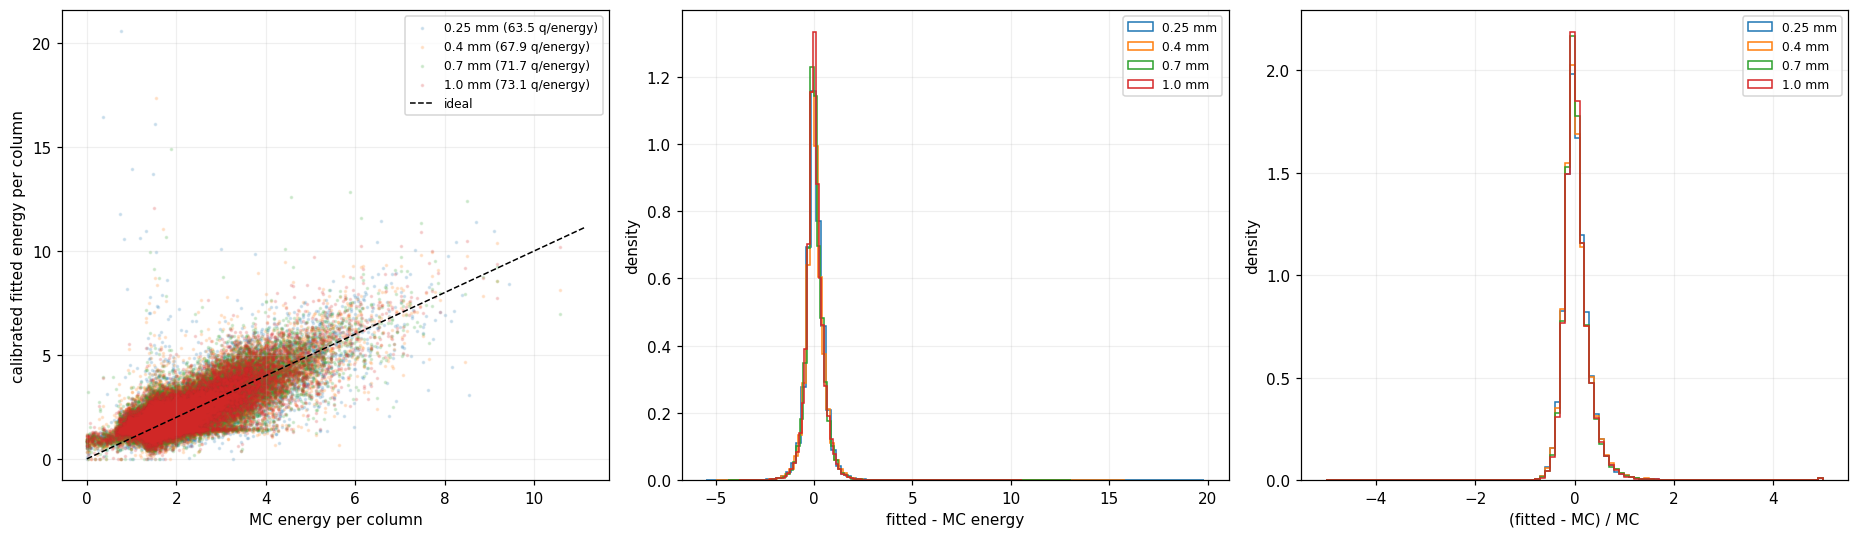

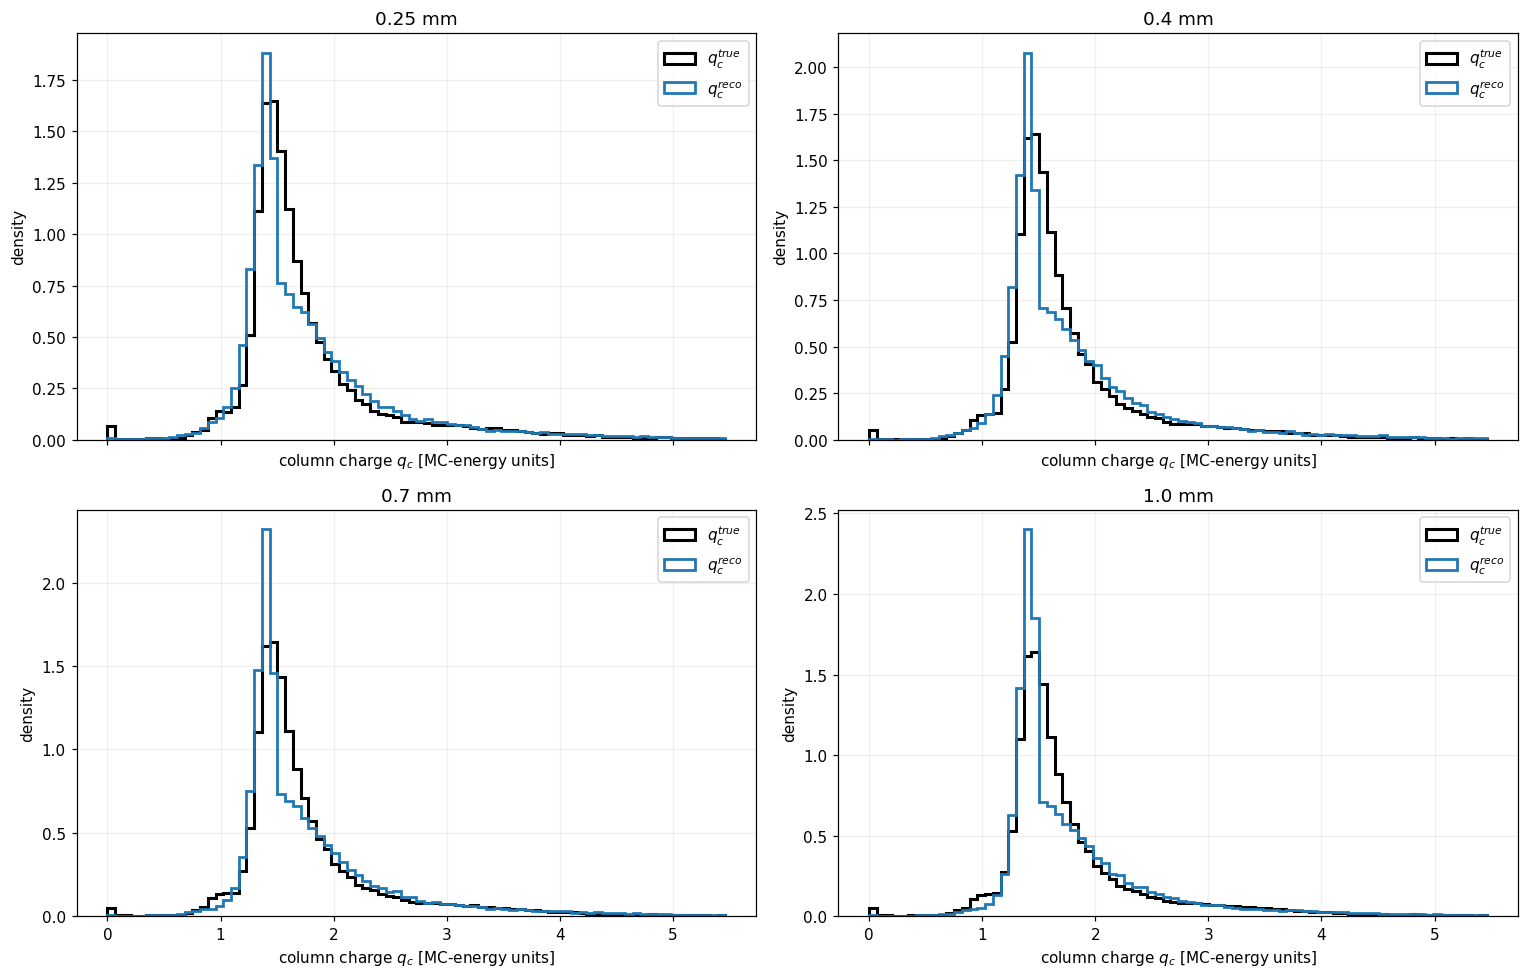

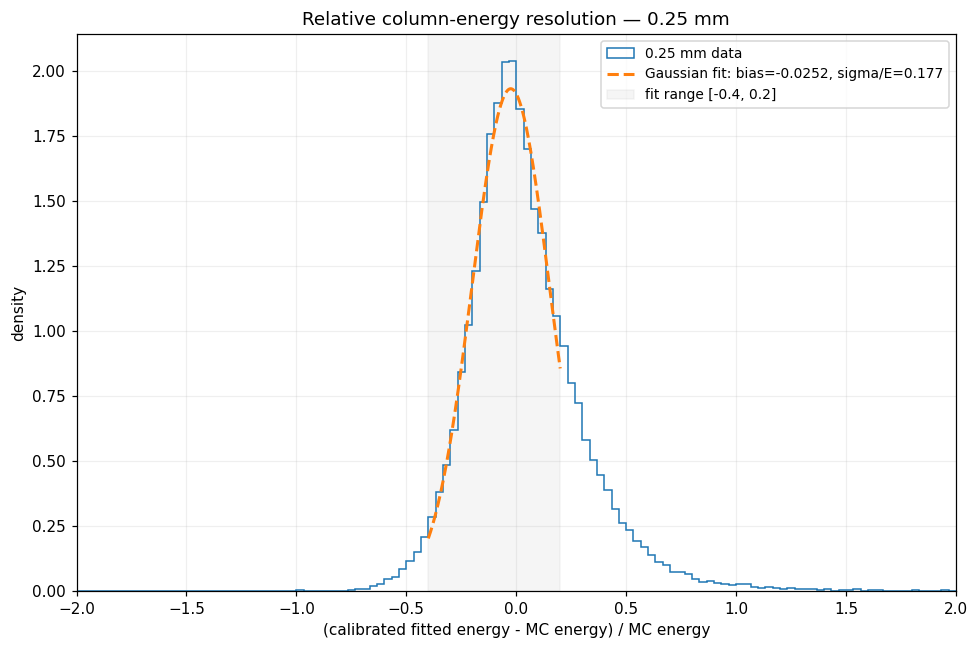

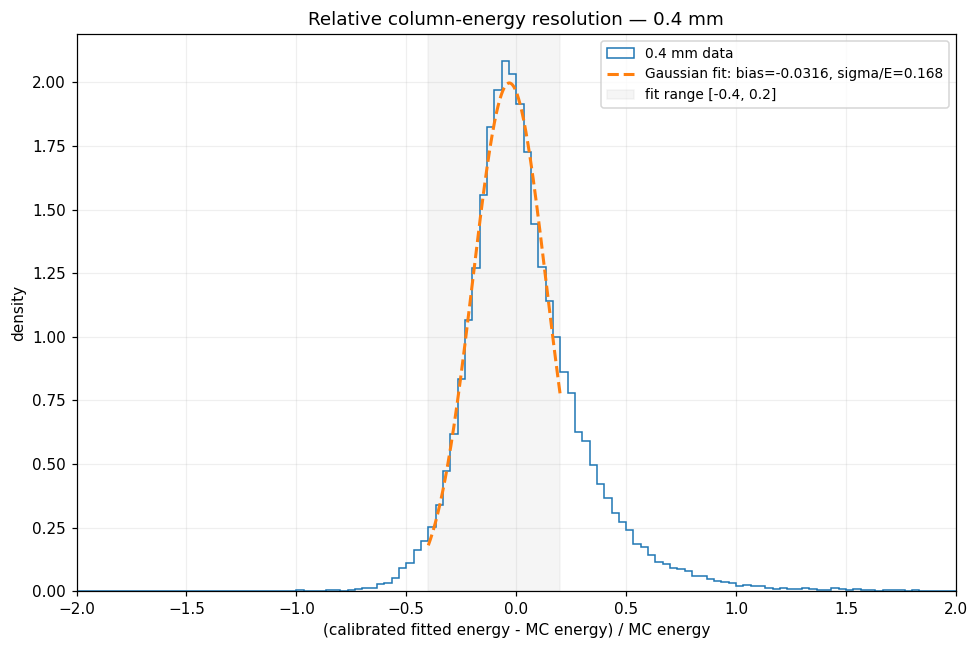

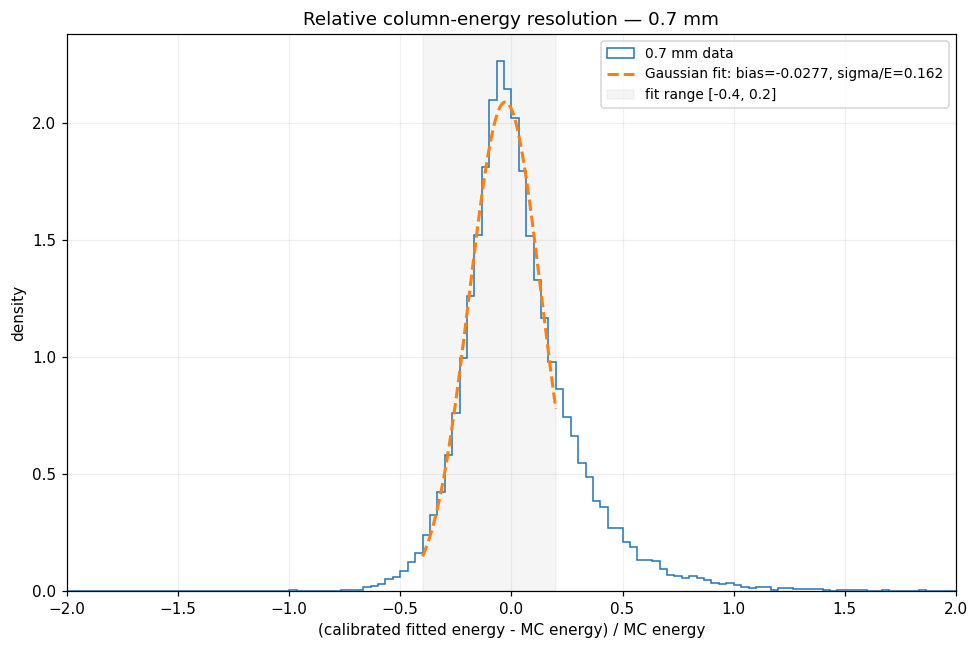

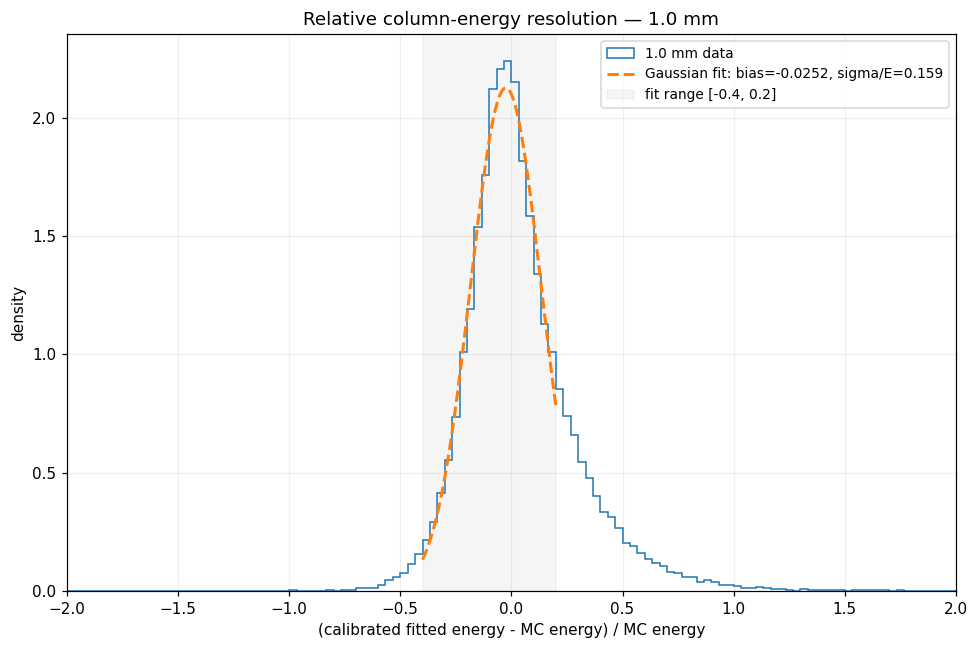

In [5]:
matched = {}
for label, study in studies.items():
    matched[label] = match_columns_to_truth(study['columns'], segments, track_points, TRUTH_MODE)
    print(f'{label}: {len(matched[label])} matched columns, scale={charge_calibration(matched[label]):.6g} charge/MC-energy')
plot_column_resolution(matched);
# All-column 1D q_c distributions. Reco is calibrated into the same units as MC truth.
QC_BINS = 80
QC_DISPLAY_RANGE = None  # e.g. (0.0, 0.08); None uses the combined 99.5% quantile
QC_DENSITY = True
QC_INCLUDE_ZERO_TRUTH = True
qc_summary, qc_figure = plot_column_charge_distributions(
    matched, bins=QC_BINS, histogram_range=QC_DISPLAY_RANGE, density=QC_DENSITY,
    include_zero_truth=QC_INCLUDE_ZERO_TRUTH)
display(qc_summary)
# Fit a pure Gaussian only inside FIT_RANGE, equivalent to ROOT's gaus fit with the R option.
COLUMN_RESIDUAL_DISPLAY_RANGE = (-2.0, 2.0)
COLUMN_RESIDUAL_FIT_RANGE = (-0.4, 0.2)
resolution_fits, resolution_figure = plot_relative_energy_resolution(
    matched, display_range=COLUMN_RESIDUAL_DISPLAY_RANGE, gaussian_fit_range=COLUMN_RESIDUAL_FIT_RANGE)
display(resolution_fits)

## Truncated-mean dE/dx

For every event and light map, the calibrated fitted energy in each column is divided by the fitted path length. Columns are sorted by dE/dx, the highest 30% are discarded, and the arithmetic mean of the remaining 70% is reported. MC truth is treated identically using the same fitted column intervals and path lengths.

fit_truncated_dedx           mc_truncated_dedx          
                       mean       std              mean       std
lightmap                                                         
0.25 mm            0.145920  0.009491          0.145588  0.004748
0.4 mm             0.146111  0.009087          0.145798  0.004910
0.7 mm             0.146408  0.007444          0.145734  0.004805
1.0 mm             0.146982  0.006718          0.145747  0.004834

,fit_peak_mean,fit_peak_sigma,fit_sigma_over_mean,mc_peak_mean,mc_peak_sigma,mc_sigma_over_mean,relative_residual_bias,relative_residual_sigma,residual_fit_low,residual_fit_high,residual_fit_entries,events
lightmap,,,,,,,,,,,,
0.25 mm,0.147606,0.004477,0.030332,0.145171,0.004113,0.028335,0.015804,0.025808,-0.07,0.15,456,505
0.4 mm,0.147379,0.004759,0.032294,0.145423,0.004535,0.031184,0.011820,0.024131,-0.07,0.15,465,505
0.7 mm,0.147155,0.004227,0.028722,0.145429,0.004251,0.029232,0.010913,0.021214,-0.07,0.15,472,505
1.0 mm,0.147944,0.003822,0.025831,0.145249,0.003805,0.026196,0.012903,0.021560,-0.07,0.15,481,505


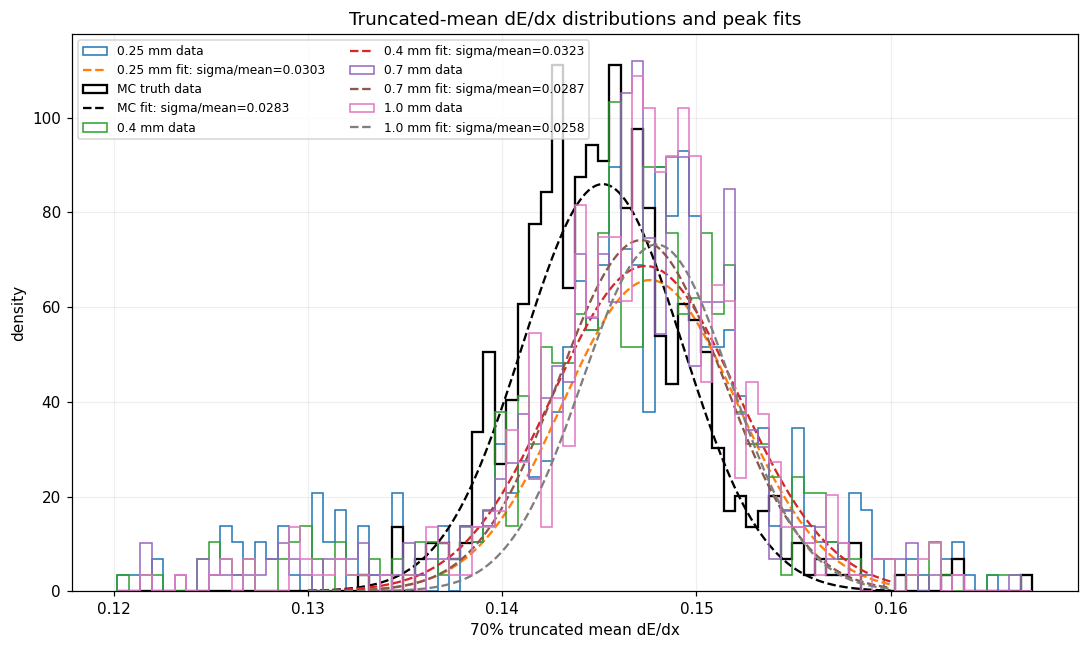

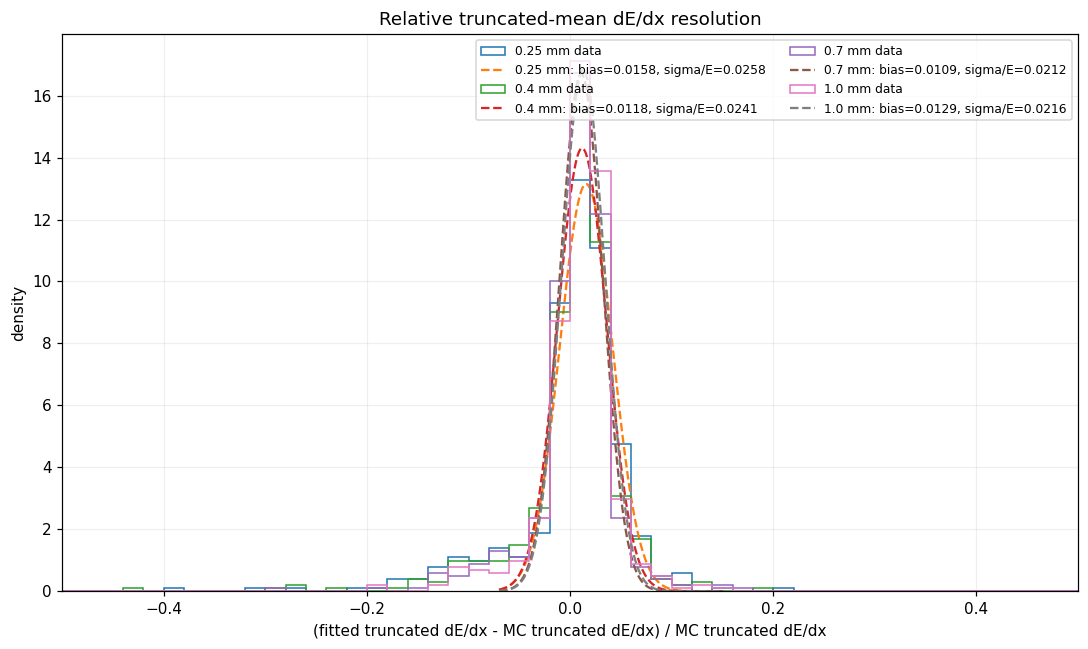

In [6]:
truncated_dedx = truncated_dedx_table(matched, discard_fraction=0.30)
display(truncated_dedx.groupby('lightmap')[['fit_truncated_dedx','mc_truncated_dedx']].agg(['mean','std']))
TRUNCATED_DEDX_RELATIVE_DISPLAY_RANGE = (-0.5, 0.5)
TRUNCATED_DEDX_RELATIVE_FIT_RANGE = (-.07, .15)
TRUNCATED_DEDX_FIT_RANGE = (0.13,0.16)  # Replace with (low, high) to fit only that part of the absolute dE/dx peak.
TRUNCATED_DEDX_RELATIVE_BINS = 50  # 0.02-wide bins over the display range; 20 bins lie inside the fit range.
dedx_resolution_fits, dedx_resolution_figures = plot_truncated_dedx_resolution(
    truncated_dedx, relative_display_range=TRUNCATED_DEDX_RELATIVE_DISPLAY_RANGE,
    relative_fit_range=TRUNCATED_DEDX_RELATIVE_FIT_RANGE,
    dedx_fit_range=TRUNCATED_DEDX_FIT_RANGE, relative_bins=TRUNCATED_DEDX_RELATIVE_BINS)
display(dedx_resolution_fits)

## Neighbour-column migration and longitudinal resolution

These cells test whether an excess in column $k$ is accompanied by an undershoot in $k+1$, as expected when correlated response patterns move charge between neighbours. They also repeat the Gaussian resolution fit after sliding sums of 1, 2 and 3 columns, measure the best signed fitted-to-MC profile lag, and quantify cumulative-profile disagreement. A true neighbouring response-vector correlation requires the internal per-column fibre response matrix, which is not stored in the current ROOT files and is therefore not approximated here.

/tmp/ipykernel_1514648/1780143907.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(neighbour_migration.groupby('lightmap').apply(lambda f: pd.Series({


,adjacent_residual_correlation,pairs
lightmap,,
0.25 mm,-0.014575,53255.0
0.4 mm,-0.107960,53595.0
0.7 mm,-0.177597,53807.0
1.0 mm,-0.232935,54188.0


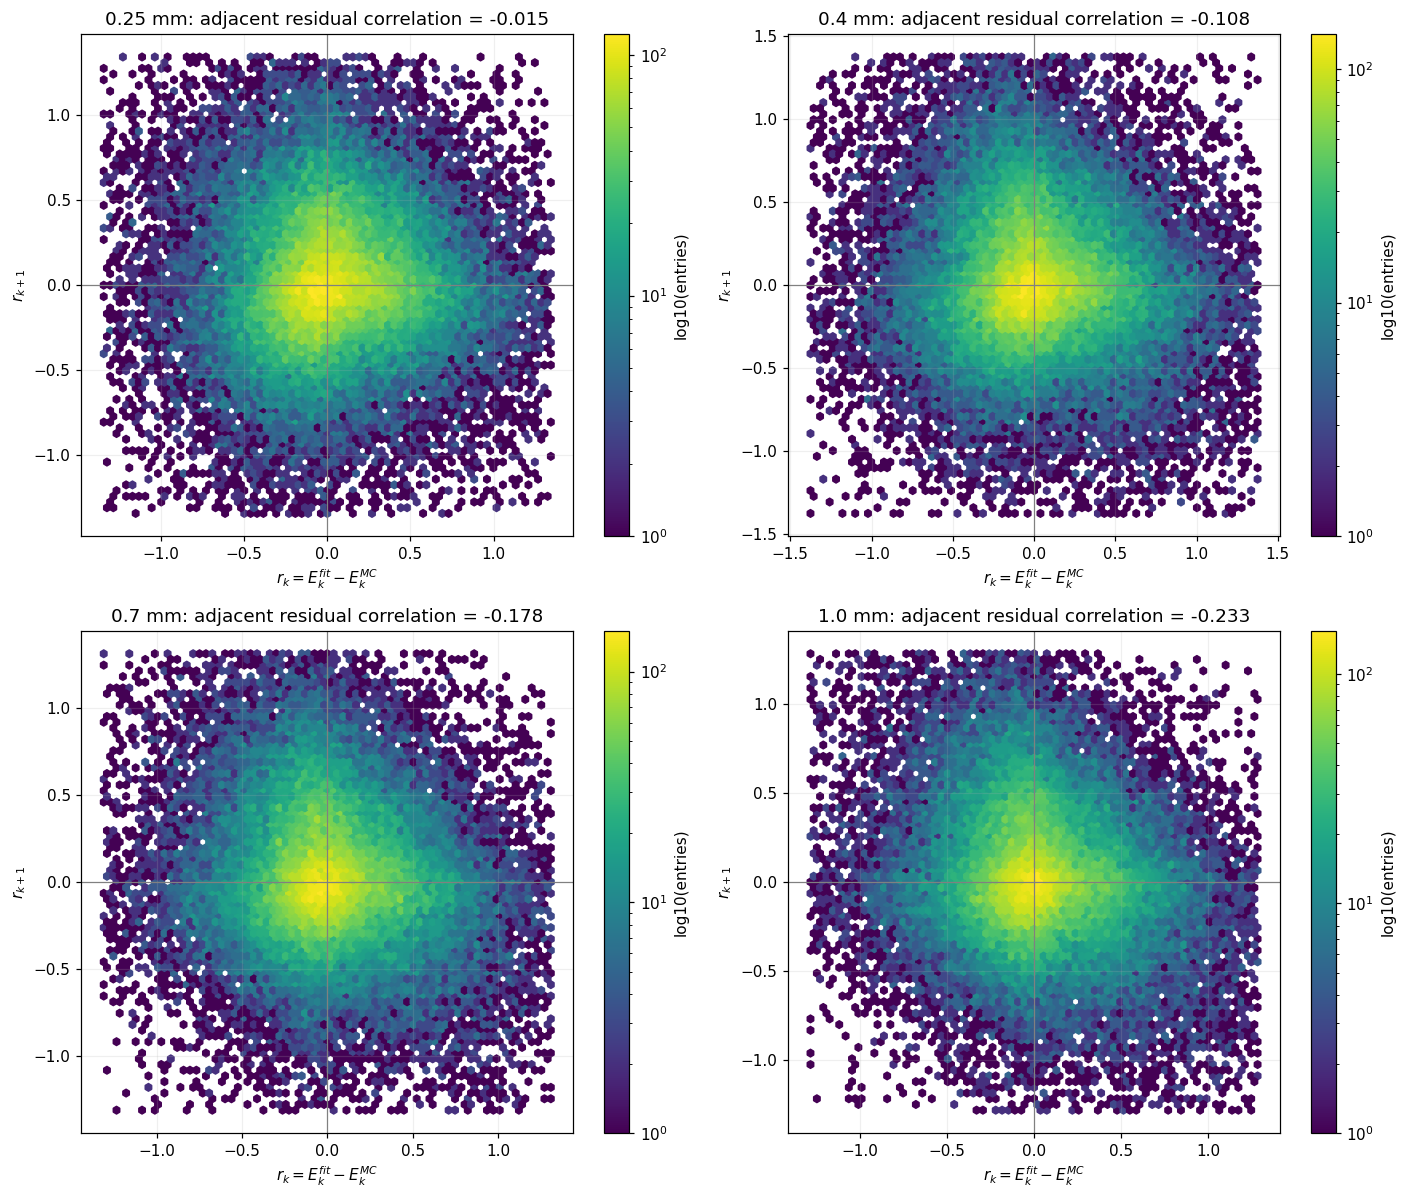

In [7]:
neighbour_migration = neighbour_migration_table(matched)
display(neighbour_migration.groupby('lightmap').apply(lambda f: pd.Series({
    'adjacent_residual_correlation': f.residual_k.corr(f.residual_next),
    'pairs': len(f)})))
plot_neighbour_migration(neighbour_migration);

,lightmap,aggregation_columns,aggregation_mm,gaussian_bias,sigma_over_E,fit_entries,all_windows
0,0.25 mm,1,10,-0.016354,0.185462,41793,53610
1,0.25 mm,2,20,0.018949,0.150832,43806,53254
2,0.25 mm,3,30,0.029201,0.128364,44212,52692
3,0.4 mm,1,10,-0.028176,0.170274,40863,54010
4,0.4 mm,2,20,0.013776,0.141961,43434,53586
5,0.4 mm,3,30,0.024980,0.118577,43709,53026
6,0.7 mm,1,10,-0.026901,0.156612,39509,54216
7,0.7 mm,2,20,0.012271,0.131000,43763,53799
8,0.7 mm,3,30,0.021746,0.110913,44344,53242
9,1.0 mm,1,10,-0.019507,0.162485,41612,54592


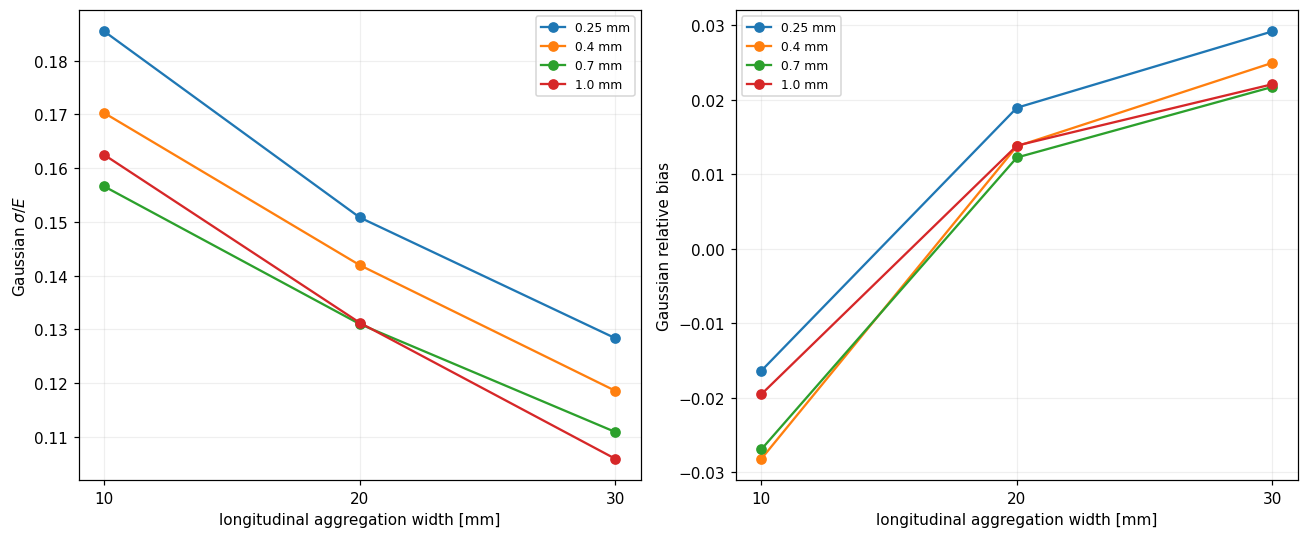

In [8]:
aggregation_resolution = aggregation_resolution_table(matched, widths=(1,2,3))
display(aggregation_resolution)
plot_aggregation_resolution(aggregation_resolution);

best_lag_columns                  maximum_cumulative_difference  \
                     mean       std median                          mean   
lightmap                                                                   
0.25 mm         -0.015842  0.281271    0.0                      0.030616   
0.4 mm          -0.009901  0.172231    0.0                      0.026428   
0.7 mm           0.003960  0.140803    0.0                      0.023502   
1.0 mm           0.003960  0.088999    0.0                      0.021014   

                              
               std    median  
lightmap                      
0.25 mm   0.025393  0.020421  
0.4 mm    0.021548  0.018287  
0.7 mm    0.020032  0.016819  
1.0 mm    0.016938  0.015902

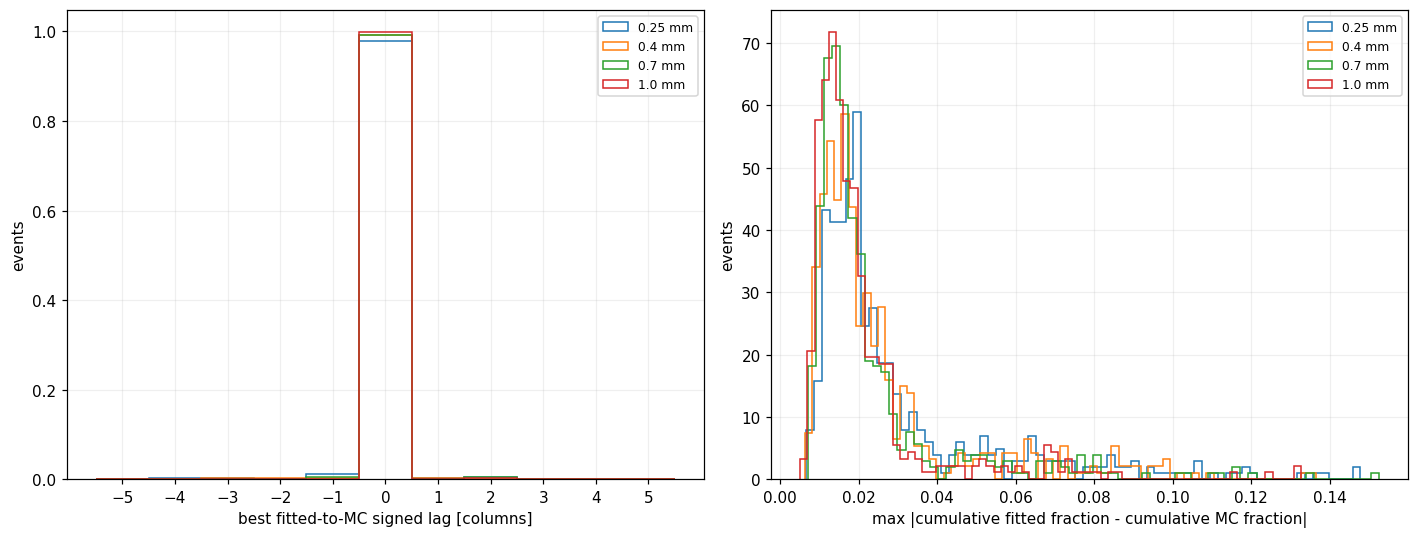

In [9]:
profile_shifts = profile_shift_table(matched, maximum_lag=5)
display(profile_shifts.groupby('lightmap')[['best_lag_columns','maximum_cumulative_difference']].agg(['mean','std','median']))
plot_profile_shifts(profile_shifts, maximum_lag=5);

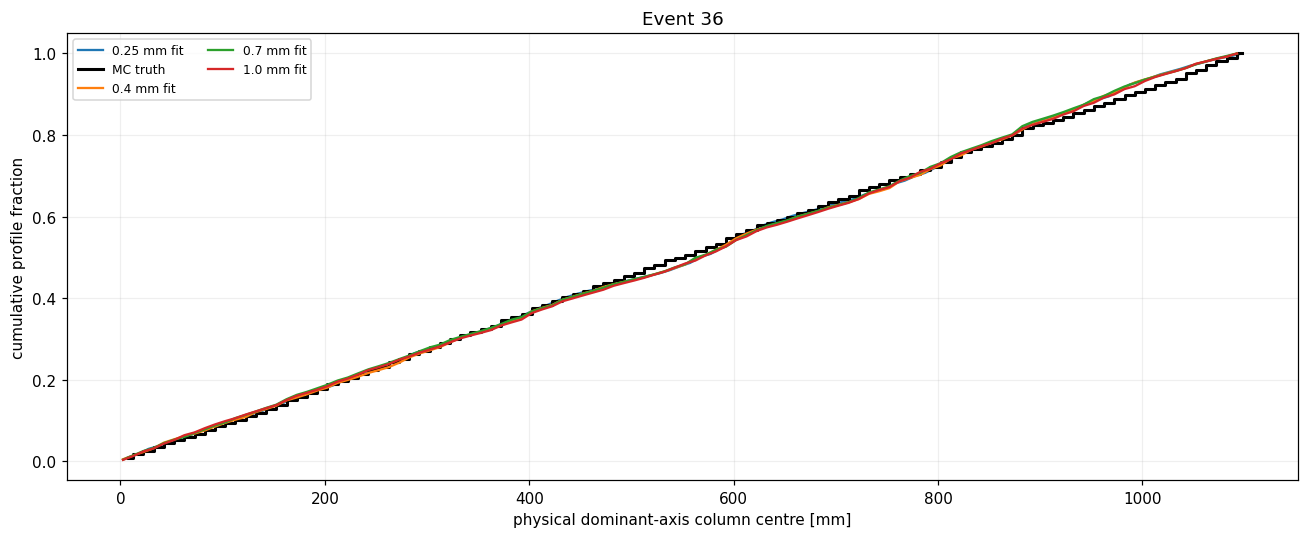

In [10]:
# Change EVENT to inspect cumulative migration in a particular event.
EVENT = 36
plot_event_cumulative_profiles(matched, EVENT);

In [11]:
# Select an event and any subset of the available light maps.
# Widget-free alternative: plot_event_profile(studies, matched, event=241)
interactive_event(studies, matched);

Output()

## Track residuals and pure-MC reference

For every `mc_virtual_segments` cube segment associated with a particle whose `mc_track_points` PDG is 13, the reconstructed residual uses that cube's start position. The pure-MC reference performs an independent 3D PCA straight-line fit to those same PDG-13 cube-start positions in every event. This reproduces the narrow reference peak without using fibre or light-map information. Column-energy truth separately uses `mc_virtual_segments.energy_deposit`, including secondary energy when `TRUTH_MODE='all'`.

In [12]:
MUON_CUBE_MATCH_DISTANCE_MM = 2.0  # used for existing files without contributor PDGs
line_residuals = segment_line_residuals(
    studies, segments, track_points, maximum_muon_match_distance_mm=MUON_CUBE_MATCH_DISTANCE_MM)
print({label: len(frame) for label, frame in line_residuals.items()})

{'MC straight-line reference': 20115, '0.25 mm': 20115, '0.4 mm': 20115, '0.7 mm': 20115, '1.0 mm': 20115}


Plotting 212 common events
{'0.25 mm': 414, '0.4 mm': 398, '0.7 mm': 375, '1.0 mm': 360}


events                      lost_from_previous  \
lightmap                     0.25 mm 0.4 mm 0.7 mm 1.0 mm            0.25 mm   
stage                                                                          
after DBSCAN                   505.0  505.0  505.0  505.0                0.0   
charge >= 1                    505.0  505.0  505.0  505.0                0.0   
common across all lightmaps    212.0  212.0  212.0  212.0              202.0   
fit result written             505.0  505.0  505.0  505.0                0.0   
input events                   505.0  505.0  505.0  505.0                0.0   
selected with MC residual      414.0  398.0  375.0  360.0                0.0   
selected: column convergence   414.0  398.0  375.0  360.0               91.0   

                                                  fraction_of_previous  \
lightmap                     0.4 mm 0.7 mm 1.0 mm              0.25 mm   
stage                                                                    
after DBSCAN                    0.0    0.0    0.0             1.000000   
charge >= 1                     0.0    0.0    0.0             1.000000   
common across all lightmaps   186.0  163.0  148.0             0.512077   
fit result written              0.0    0.0    0.0             1.000000   
input events                    0.0    0.0    0.0             1.000000   
selected with MC residual       0.0    0.0    0.0             1.000000   
selected: column convergence  107.0  130.0  145.0             0.819802   

                                                            
lightmap                        0.4 mm    0.7 mm    1.0 mm  
stage                                                       
after DBSCAN                  1.000000  1.000000  1.000000  
charge >= 1                   1.000000  1.000000  1.000000  
common across all lightmaps   0.532663  0.565333  0.588889  
fit result written            1.000000  1.000000  1.000000  
input events                  1.000000  1.000000  1.000000  
selected with MC residual     1.000000  1.000000  1.000000  
selected: column convergence  0.788119  0.742574  0.712871

events                      fraction_of_input  \
lightmap                      0.25 mm 0.4 mm 0.7 mm 1.0 mm           0.25 mm   
stage                                                                          
column fit available            505.0  505.0  505.0  505.0          1.000000   
column fit converged            414.0  398.0  375.0  360.0          0.819802   
geometry and column converged     0.0    0.0    0.0    0.0          0.000000   
geometry status 0                 0.0    0.0    0.0    0.0          0.000000   

                                                             
lightmap                         0.4 mm    0.7 mm    1.0 mm  
stage                                                        
column fit available           1.000000  1.000000  1.000000  
column fit converged           0.788119  0.742574  0.712871  
geometry and column converged  0.000000  0.000000  0.000000  
geometry status 0              0.000000  0.000000  0.000000

,sample,component,gaussian_mean_mm,gaussian_sigma_mm,fit_low_mm,fit_high_mm,fit_entries,distance_68_mm
0,MC straight-line reference,rx,0.000607,0.055235,-1.5,1.5,8990,NaN
1,MC straight-line reference,ry,-0.015566,0.614882,-1.5,1.5,7433,NaN
2,MC straight-line reference,rz,0.005929,0.601116,-1.5,1.5,7419,NaN
3,MC straight-line reference,point_resolution_summary,NaN,0.609291,NaN,NaN,8990,1.305073
4,0.25 mm,rx,-0.001775,0.096165,-1.5,1.5,8977,NaN
5,0.25 mm,ry,0.024689,1.252900,-1.5,1.5,5750,NaN
6,0.25 mm,rz,0.042994,1.190401,-1.5,1.5,5621,NaN
7,0.25 mm,point_resolution_summary,NaN,1.223940,NaN,NaN,8990,2.726446
8,0.4 mm,rx,-0.008752,0.093674,-1.5,1.5,8977,NaN
9,0.4 mm,ry,0.046400,1.213118,-1.5,1.5,5595,NaN


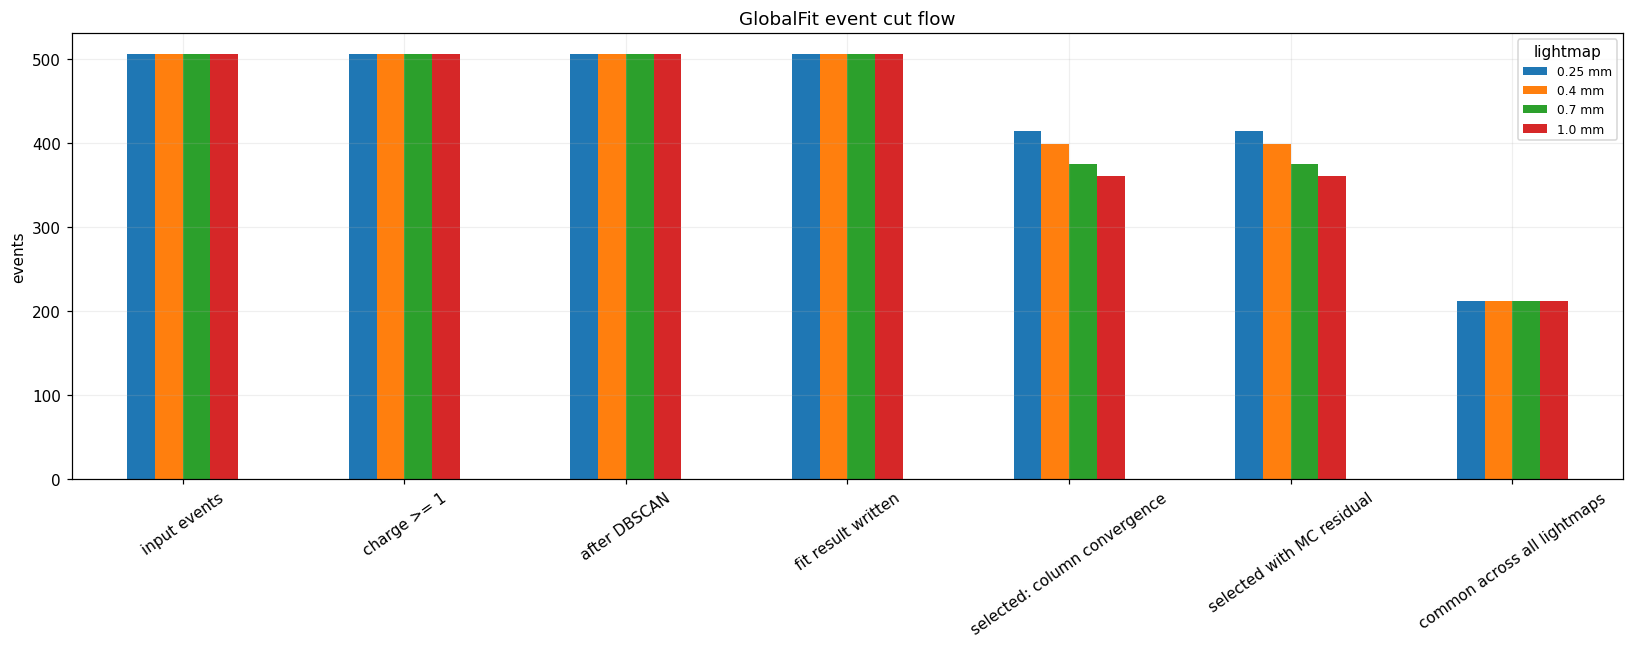

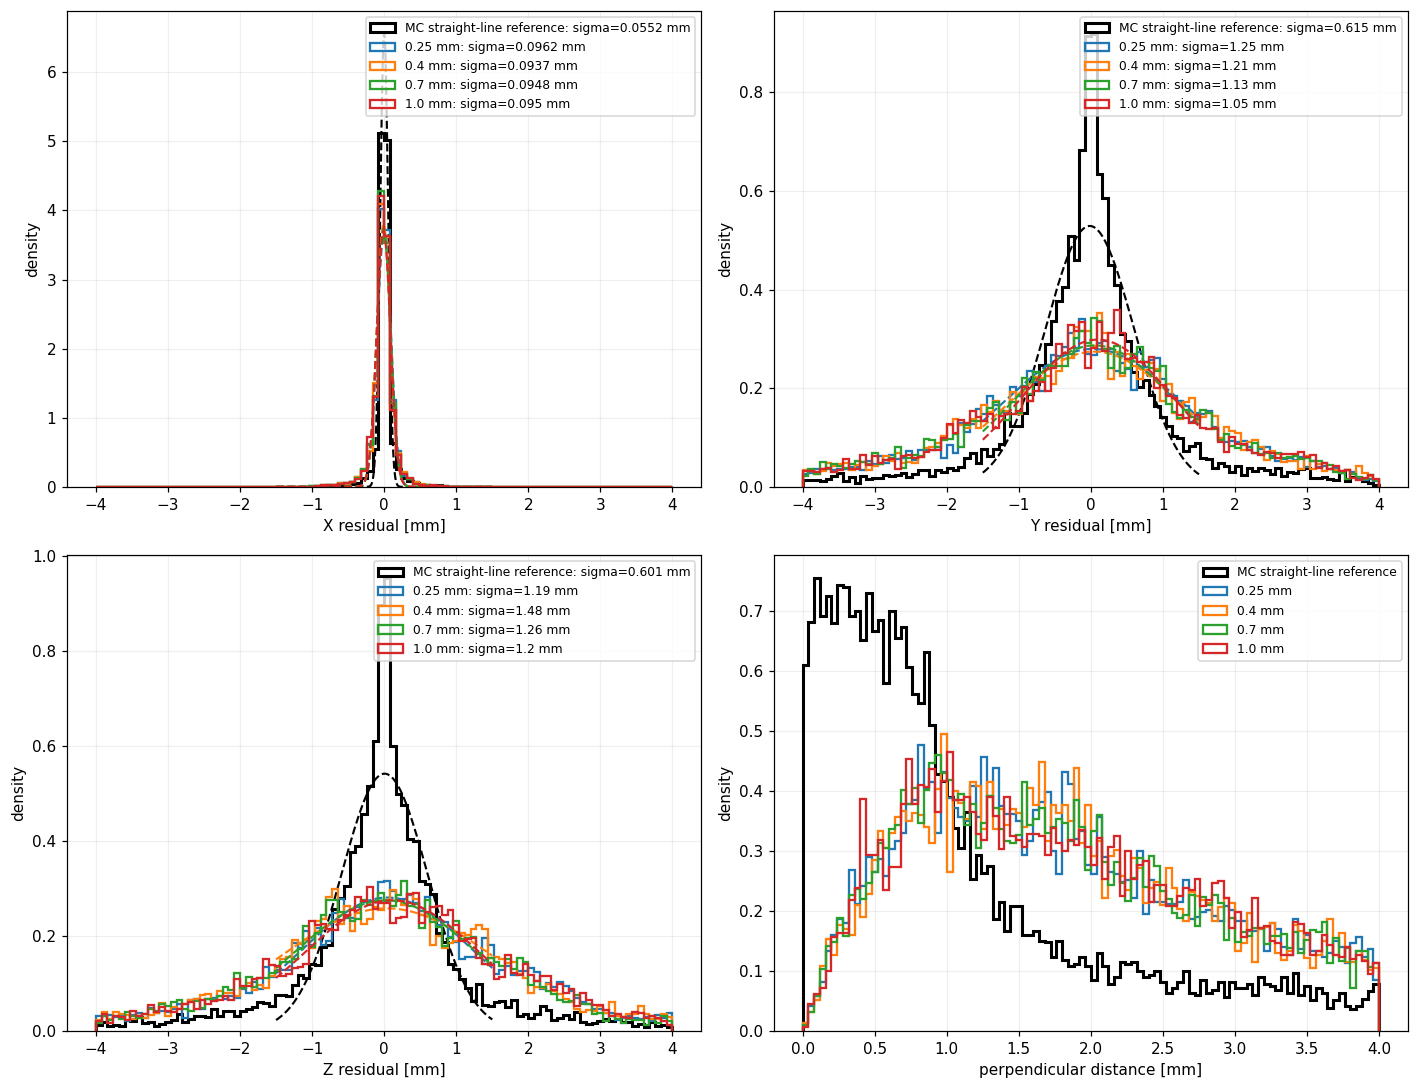

In [13]:
# Statistics-rich residual comparison over all events.
# CONVERGENCE: 'column' (recommended), 'geometry', 'both', or 'none'.
# With COMMON_EVENTS=True, all light maps and MC use the same event intersection.
EVENT = 'ALL'
CONVERGENCE = 'column'
COMMON_EVENTS = True
selected_residuals, accepted_events, plotted_events = filter_line_residuals(
    line_residuals, studies, EVENT, CONVERGENCE, COMMON_EVENTS)
print(f'Plotting {len(plotted_events)} common events')
print({label: len(events) for label, events in accepted_events.items()})
event_losses, cutflow_common_events = event_cutflow(studies, line_residuals, CONVERGENCE)
display(event_losses[event_losses.category == 'stepwise'].pivot(
    index='stage', columns='lightmap', values=['events','lost_from_previous','fraction_of_previous']))
display(event_losses[event_losses.category == 'diagnostic'].pivot(
    index='stage', columns='lightmap', values=['events','fraction_of_input']))
cutflow_figure = plot_event_cutflow(event_losses)
RESIDUAL_DISPLAY_MAX_MM = 4.0
RESIDUAL_GAUSSIAN_FIT_RANGE_MM = (-1.5, 1.5)
residual_resolution, residual_figure = plot_line_residuals(
    selected_residuals, distance_max=RESIDUAL_DISPLAY_MAX_MM,
    signed_fit_range=RESIDUAL_GAUSSIAN_FIT_RANGE_MM)
display(residual_resolution)

## Optional MIP-prior comparison

These cells run only when the selected files contain an enabled MIP prior and the retained unregularized column solution. Older ROOT files remain fully supported and simply skip this section. Both reconstructed curves use the same stored independent charge-to-energy scale, so a regularization-induced normalization shift remains visible.

In [14]:
mip_variants = mip_prior_variants(studies, matched)
mip_summary = mip_prior_summary(studies, mip_variants)
if mip_summary.empty:
    print('No enabled MIP-prior solution found; continuing with the standard analysis only.')
else:
    display(mip_summary)

,events,prior_converged,prior_stalled,prior_converged_fraction,eligible_columns,charge_per_energy,mean_regularization_shift,rms_regularization_shift,median_prior_iterations,median_prior_penalty
lightmap,,,,,,,,,,
0.25 mm,505,504,0,0.99802,52808,61.795754,0.027558,0.221634,27.0,0.010723
0.4 mm,505,505,0,1.00000,53154,65.983259,0.026442,0.274449,37.0,0.009400
0.7 mm,505,504,0,0.99802,53362,69.671914,0.024055,0.293159,44.0,0.008015
1.0 mm,505,505,0,1.00000,53741,71.471404,0.023310,0.316787,50.0,0.006997


,lightmap,solution,columns,absolute_residual_mean,absolute_residual_std,absolute_residual_rms,fractional_residual_mean,fractional_residual_std,fractional_residual_rms
0,0.25 mm,without regularization,53492,0.060858,0.633317,0.636228,0.046381,0.392775,0.395500
1,0.25 mm,with MIP regularization,53492,0.088416,0.542680,0.549831,0.070930,0.331524,0.339024
2,0.4 mm,without regularization,53878,0.065154,0.642164,0.645455,0.048709,0.380940,0.384038
3,0.4 mm,with MIP regularization,53878,0.091596,0.520725,0.528714,0.073009,0.294411,0.303326
4,0.7 mm,without regularization,54077,0.065745,0.630052,0.633467,0.047538,0.371820,0.374843
5,0.7 mm,with MIP regularization,54077,0.089800,0.498198,0.506222,0.071005,0.277827,0.286754
6,1.0 mm,without regularization,54448,0.054181,0.625046,0.627384,0.040932,0.368475,0.370738
7,1.0 mm,with MIP regularization,54448,0.077491,0.477518,0.483760,0.064462,0.263477,0.271246


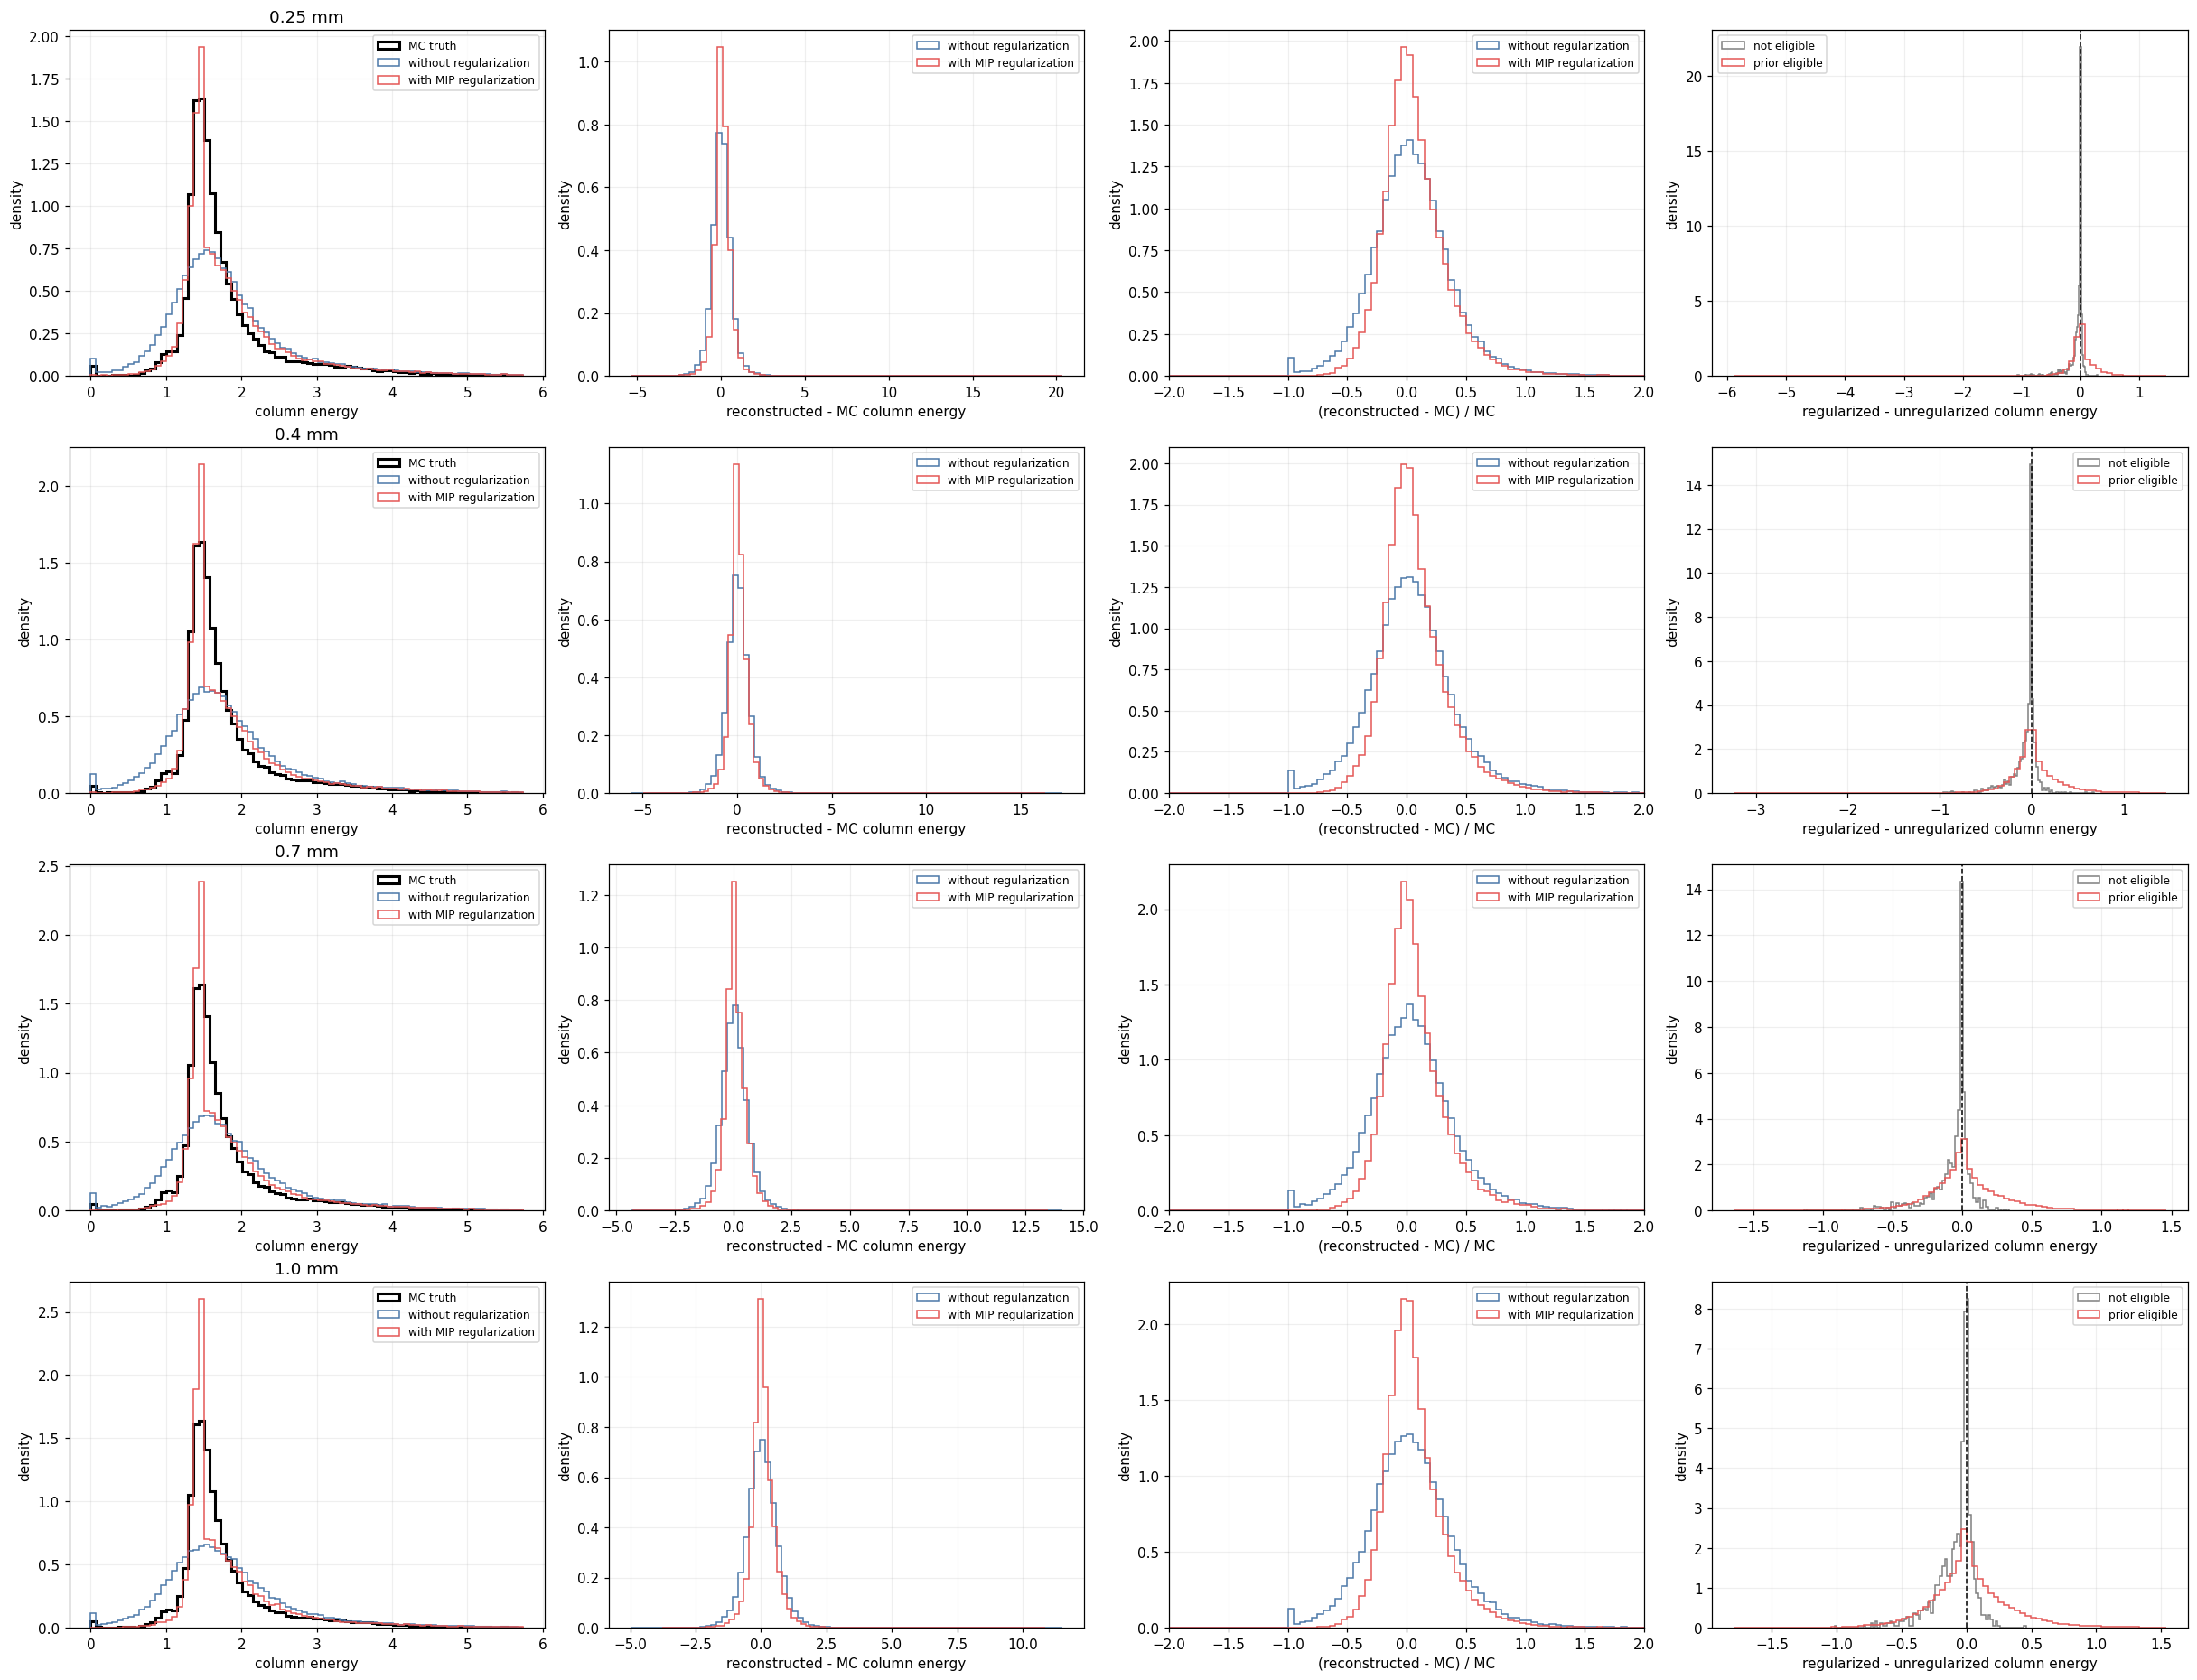

In [15]:
MIP_QC_BINS = 80
MIP_ENERGY_DISPLAY_RANGE = None  # e.g. (0.0, 4.0)
MIP_FRACTIONAL_RESIDUAL_RANGE = (-2.0, 2.0)
MIP_MINIMUM_FRACTIONAL_TRUTH_ENERGY = 0.5
mip_comparison_figure, mip_residual_summary = plot_mip_charge_comparison(
    mip_variants, bins=MIP_QC_BINS, energy_range=MIP_ENERGY_DISPLAY_RANGE,
    fractional_range=MIP_FRACTIONAL_RESIDUAL_RANGE,
    minimum_fractional_truth_energy=MIP_MINIMUM_FRACTIONAL_TRUTH_ENERGY)
if not mip_residual_summary.empty:
    display(mip_residual_summary)

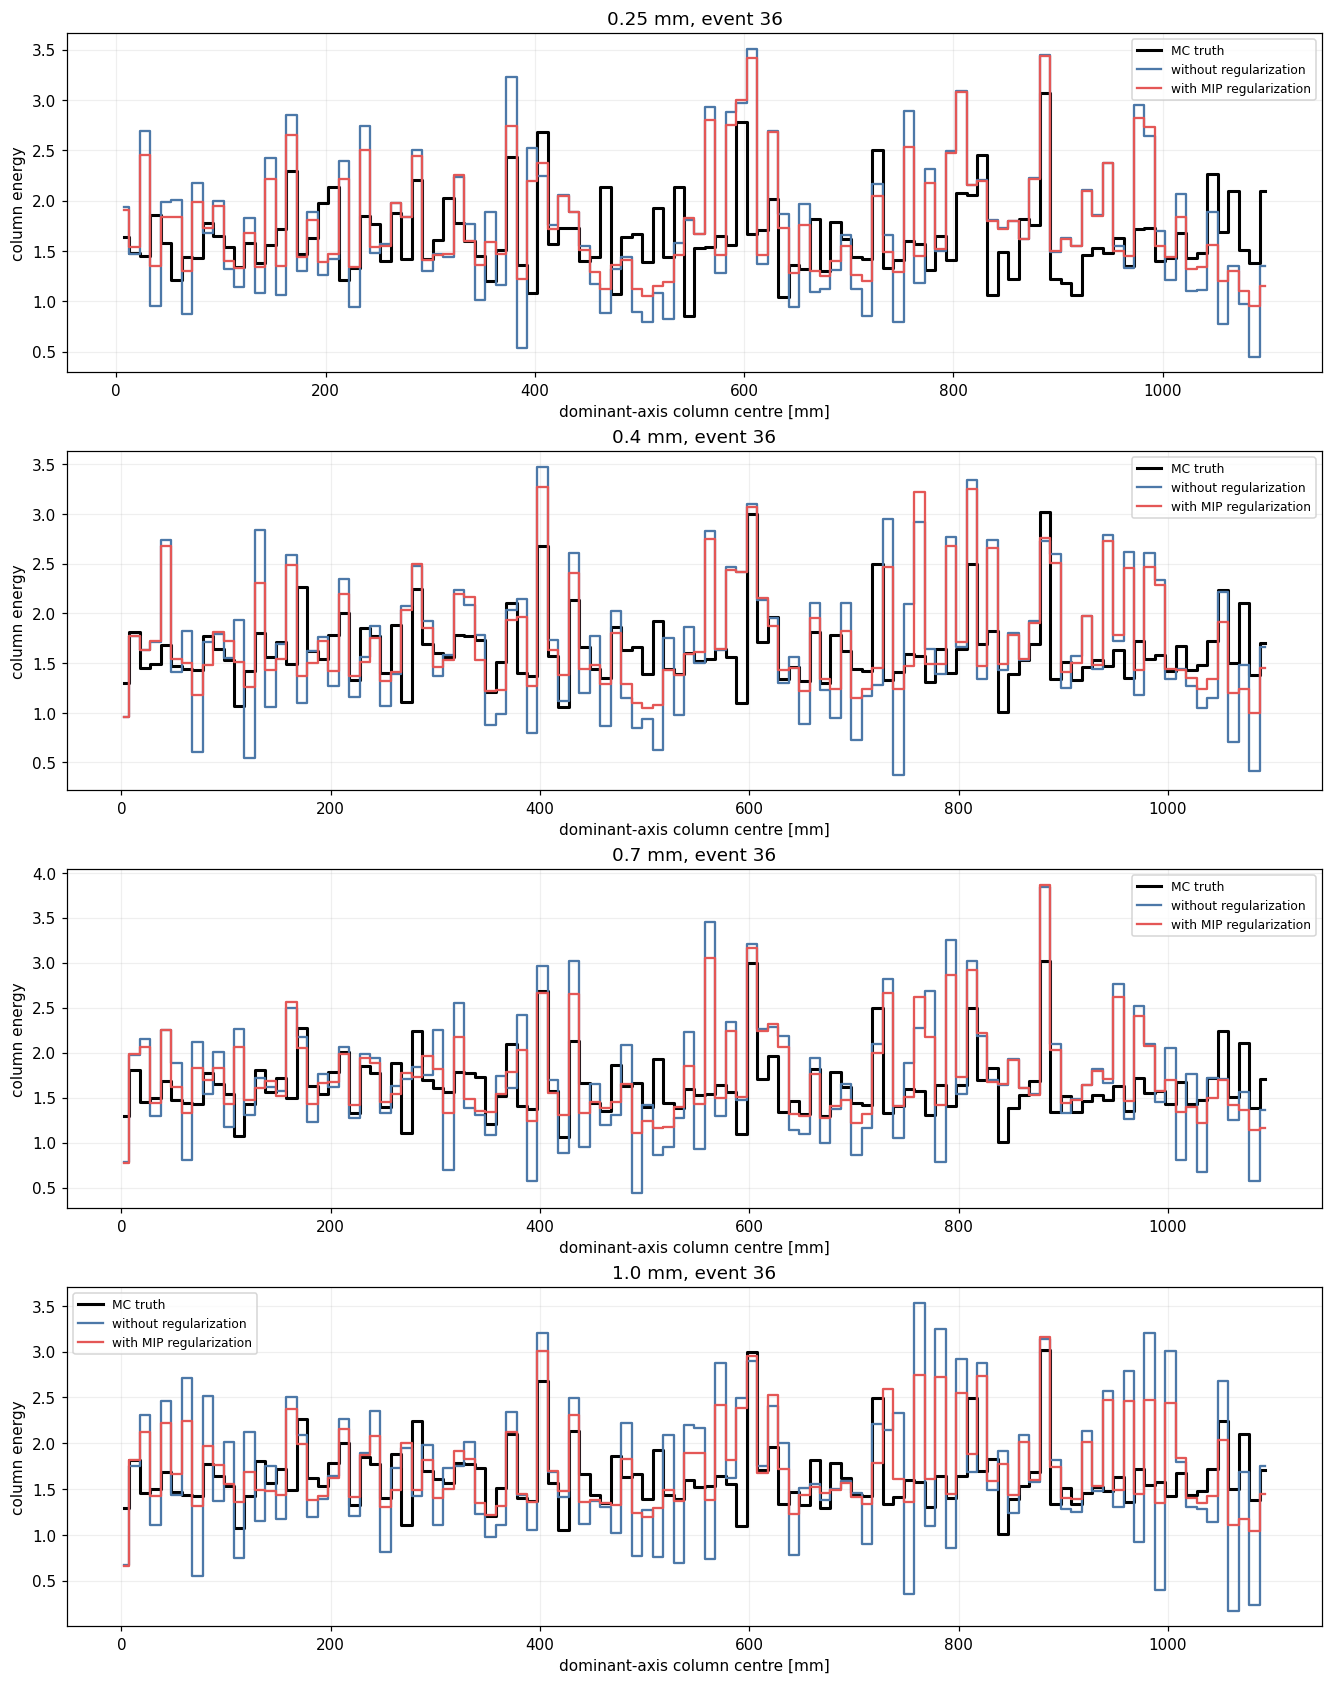

In [16]:
MIP_EVENT = 36
mip_event_figure = plot_mip_event_profiles(mip_variants, MIP_EVENT)

## Interpretation cautions

- `status != 0` concerns only the first-stage geometry minimizer; inspect EDM and direction stability as well.
- Column EM convergence does not imply that a single straight track is a good event model.
- High-energy delta electrons and other secondaries can dominate column residuals and fibre $\chi^2$.
- DBSCAN holes change which fibre measurements enter the fit. Compare `observations_before_clustering` and `observations_after_dbscan`.
- The nominal column $\chi^2/\mathrm{ndof}$ subtracts every active column parameter, although neighbouring responses are correlated; NLL is the optimized quantity.
- Absolute fitted-energy residuals depend on the global charge-to-energy calibration. Normalized event profiles isolate longitudinal-shape agreement.